In [7]:
# Importing all necessary libraries for this analysis and prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Loading the dataset needed and skipping rows cos when i reviewed the dataset,
# It had some rows that would conflict numpy if i had continued like that.

world_bank = pd.read_csv("API_SL.UEM.1524.ZS_DS2_en_csv_v2_331568.csv", skiprows=4)
nigeria = world_bank[world_bank["Country Name"] == "Nigeria"]

In [9]:
nigeria.head(20)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
173,Nigeria,NGA,"Unemployment, youth total (% of total labor fo...",SL.UEM.1524.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,9.707,10.138,10.418,10.842,8.991,6.024,5.131,5.088,5.34,NaN


In [11]:
# This is just to keep only my year columns cos it could be confusing to use the default
# Why: Before reshaping or carrying on, we need to know which columns are year columns (as opposed to "Country Name", "Country Code", etc). This line builds a list of just the columns whose names are pure numbers ("1991", "1992"...) in the dataset
year_columns = [col for col in world_bank.columns if col.isdigit()]

In [13]:

nigeria_long = nigeria.melt(id_vars=["Country Name"], value_vars=year_columns,
                           var_name="Year", value_name="Youth_Unemployment_Rate")

# This line was done because even though "Year" now holds things like 1991, pandas still thinks of them as text because they came from column headers, which are always text.
nigeria_long["Year"] = nigeria_long["Year"].astype(int)

# With this, i'm dropping years with no data eg(1960:NaN)
nigeria_long = nigeria_long.dropna()

# I am doing this because after melting (nigeria.melt), rows aren't guaranteed to be in year order. Sorting makes sure our eventual line chart draws left-to-right chronologically instead of jumping around.
nigeria_long = nigeria_long.sort_values("Year")

nigeria_long

,Country Name,Year,Youth_Unemployment_Rate
31,Nigeria,1991,7.426
32,Nigeria,1992,7.242
33,Nigeria,1993,7.556
34,Nigeria,1994,7.580
35,Nigeria,1995,7.700
36,Nigeria,1996,7.542
37,Nigeria,1997,7.452
38,Nigeria,1998,7.410
39,Nigeria,1999,7.552
40,Nigeria,2000,7.571


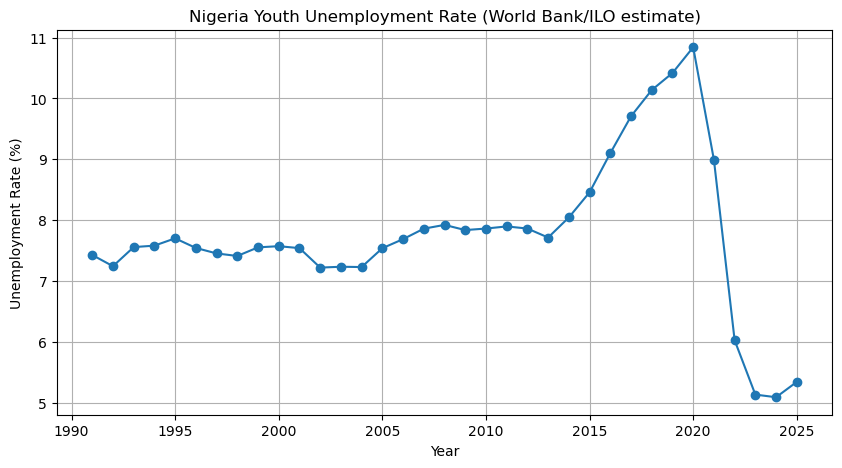

In [14]:
plt.figure(figsize=(10,5))
plt.plot(nigeria_long["Year"], nigeria_long["Youth_Unemployment_Rate"], marker="o")
plt.title("Nigeria Youth Unemployment Rate (World Bank/ILO estimate)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

In [15]:
# The methodology changed with the Q4 2022 NLFS rollout.
# We treat 2022 as the boundary year between the two regimes.
BREAK_YEAR = 2022

old_method = nigeria_long[nigeria_long["Year"] < BREAK_YEAR]
new_method = nigeria_long[nigeria_long["Year"] >= BREAK_YEAR]

print("Old methodology years:", old_method["Year"].min(), "-", old_method["Year"].max())
print("New methodology years:", new_method["Year"].min(), "-", new_method["Year"].max())

Old methodology years: 1991 - 2021
New methodology years: 2022 - 2025


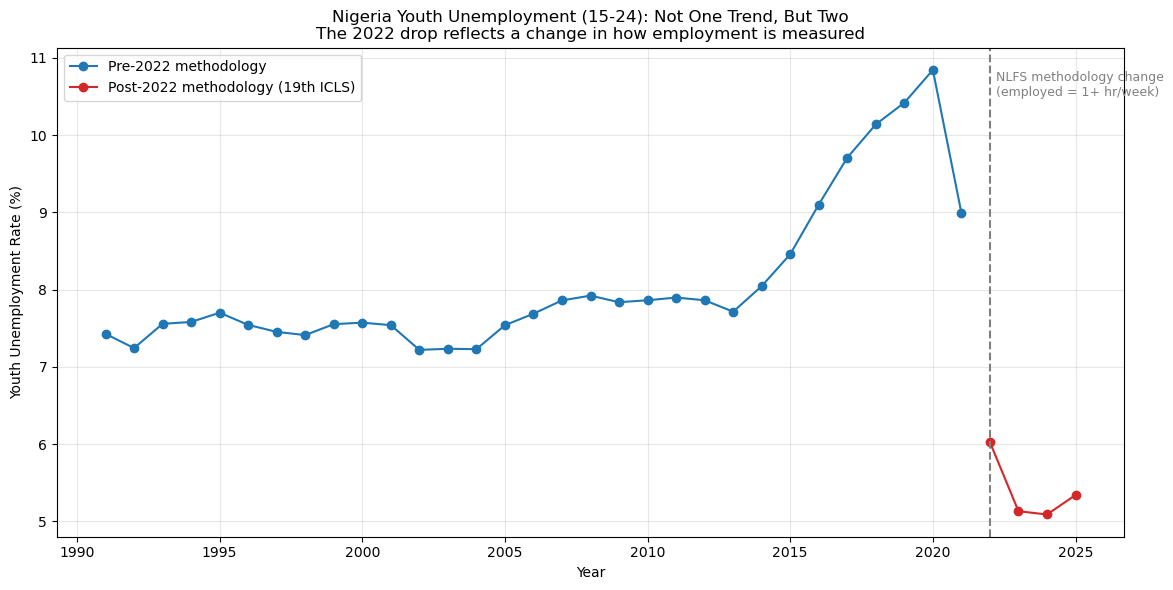

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

# Two separate line calls = two separate lines, with a visible gap between them
ax.plot(old_method["Year"], old_method["Youth_Unemployment_Rate"],
        marker="o", color="#1f77b4", label="Pre-2022 methodology")
ax.plot(new_method["Year"], new_method["Youth_Unemployment_Rate"],
        marker="o", color="#d62728", label="Post-2022 methodology (19th ICLS)")

# Mark the break itself
ax.axvline(x=BREAK_YEAR, color="grey", linestyle="--", linewidth=1.5)
ax.text(BREAK_YEAR + 0.2, 10.5,
        "NLFS methodology change\n(employed = 1+ hr/week)",
        fontsize=9, color="grey")

ax.set_title("Nigeria Youth Unemployment (15-24): Not One Trend, But Two\n"
             "The 2022 drop reflects a change in how employment is measured",
             fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Youth Unemployment Rate (%)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Section B
## Who is worst hit: the education paradox

In [ ]:
# I'm going to enter this data manually because the NBS Q2 2024 report already has it
# And this would make quite a base for this segment



In [17]:
education_data = pd.DataFrame({
    "Education_level": ["No Education", "Primary", "Lower Secondary", "Upper Secondary", "Post Secondary"],
    "Youth_Unemployment_Rate": [5.0, 3.1, 9.5, 18.3, 18.3],
    "NEET_Rate": [11.5, 4.8, 22.9, 19.7, 19.7],
    "Informal_Employment_Rate": [99.0, 97.9, 94.7, 67.1, 26.6]
})

education_data

,Education_level,Youth_Unemployment_Rate,NEET_Rate,Informal_Employment_Rate
0,No Education,5.0,11.5,99.0
1,Primary,3.1,4.8,97.9
2,Lower Secondary,9.5,22.9,94.7
3,Upper Secondary,18.3,19.7,67.1
4,Post Secondary,18.3,19.7,26.6


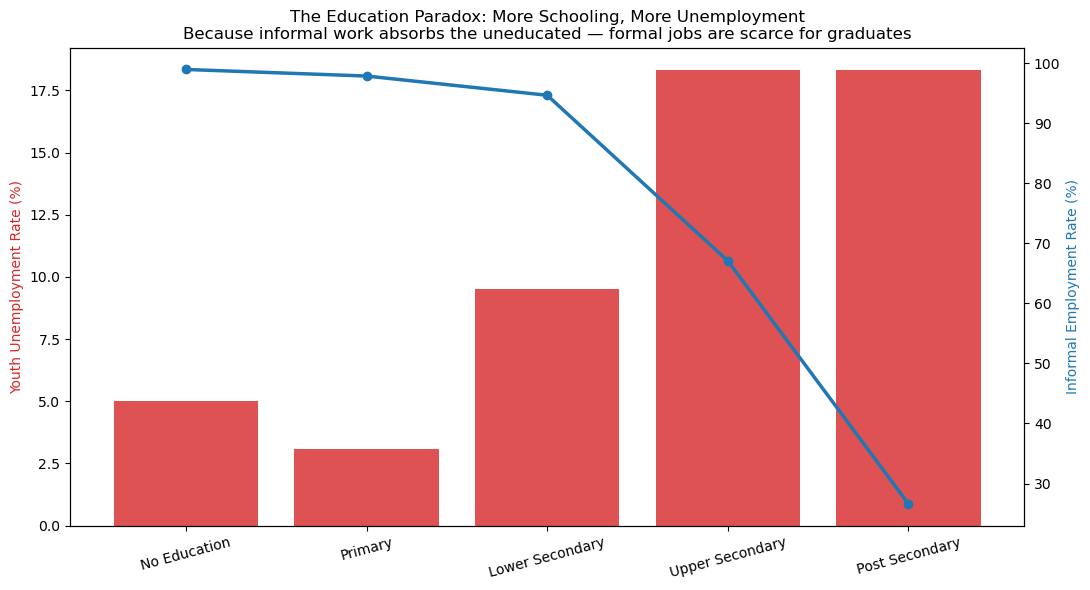

In [19]:
fig, ax1 = plt.subplots(figsize=(11, 6))

x = range(len(education_data))
ax1.bar(x, education_data["Youth_Unemployment_Rate"], color="#d62728", alpha=0.8, label="Youth Unemployment Rate (%)")
ax1.set_ylabel("Youth Unemployment Rate (%)", color="#d62728")
ax1.set_xticks(x)
ax1.set_xticklabels(education_data["Education_level"], rotation=15)

# Second y-axis sharing the same x-axis, for informality
ax2 = ax1.twinx()
ax2.plot(x, education_data["Informal_Employment_Rate"], color="#1f77b4", marker="o", linewidth=2.5, label="Informal Employment Rate (%)")
ax2.set_ylabel("Informal Employment Rate (%)", color="#1f77b4")

ax1.set_title("The Education Paradox: More Schooling, More Unemployment\n"
              "Because informal work absorbs the uneducated — formal jobs are scarce for graduates", fontsize=12)
fig.tight_layout()
plt.show()

# Section C
## Now into our Forcasting Segment,

In [23]:
# On this, Q4 2023 was not published in my reports, therefore we have a real gap not an error
# Youth unemployment rate (15-24), and this is gotten from NBS NLFS quarterly reports
quarterly_data = pd.DataFrame({
    "Quarter": ["Q4 2022", "Q1 2023", "Q2 2023", "Q3 2023", "Q1 2024", "Q2 2024"],
    "Quarter_Numeric": [2022.75, 2023.00, 2023.25, 2023.50, 2024.00, 2024.25],
    "Youth_Unemployment_Rate": [8.3, 6.9, 7.2, 8.6, 8.4, 6.5]
})

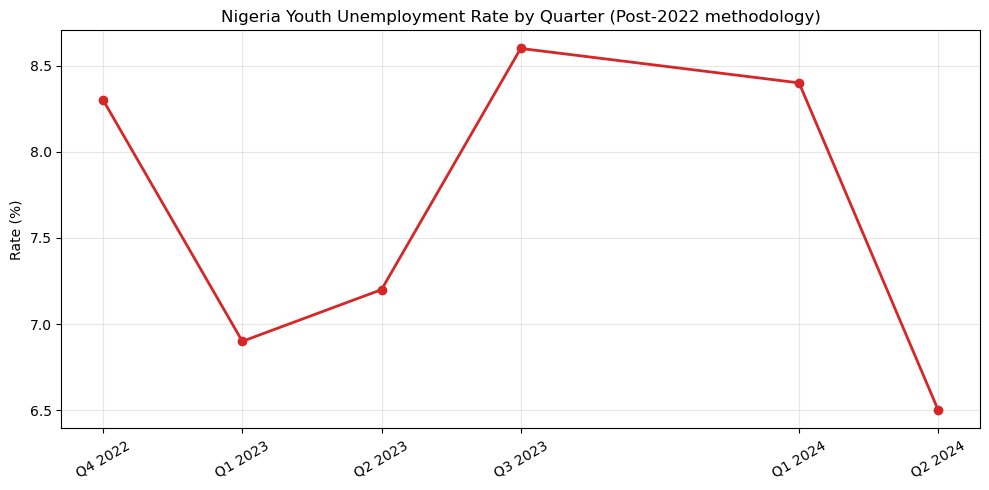

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(quarterly_data["Quarter_Numeric"], quarterly_data["Youth_Unemployment_Rate"],
        marker="o", color="#d62728", linewidth=2)
ax.set_xticks(quarterly_data["Quarter_Numeric"])
ax.set_xticklabels(quarterly_data["Quarter"], rotation=30)
ax.set_title("Nigeria Youth Unemployment Rate by Quarter (Post-2022 methodology)")
ax.set_ylabel("Rate (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.linear_model import LinearRegression

X = quarterly_data[["Quarter_Numeric"]]
y = quarterly_data["Youth_Unemployment_Rate"]

model = LinearRegression()
model.fit(X, y)

# Does a straight line actually fit this data?, Let's find out.
r_squared = model.score(X, y)
print(f"R-squared: {r_squared:.3f}")

# Forecast the next 3 quarters
future_quarters = pd.DataFrame({"Quarter_Numeric": [2024.50, 2024.75, 2025.00]})
future_quarters["Predicted_Rate"] = model.predict(future_quarters[["Quarter_Numeric"]])
future_quarters["Quarter"] = ["Q3 2024", "Q4 2024", "Q1 2025"]

future_quarters

R-squared: 0.036


,Quarter_Numeric,Predicted_Rate,Quarter
0,2024.50,7.347205,Q3 2024
1,2024.75,7.274534,Q4 2024
2,2025.00,7.201863,Q1 2025
